### DATA COLLECTION AND LOADING

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time import time
import sklearn

 #pretty display for nb
%matplotlib inline

In [130]:
df = pd.read_csv("diabetes.csv")

### data inspection

In [131]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [132]:
df  #9features

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [133]:
df.info()  #Non-Null Count- How many rows have a real value (not missing) but 0 is used above instead of unknown so pandas don't see 0 as null
           #Dtype- What kind of value it is in memory

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [134]:
df.shape

(768, 9)

### EXPLORATORY DATA ANALYSIS- understanding data

In [135]:
df.describe() #to see means and min/max

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [136]:
print(df.columns.tolist()) #to get list of columns

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [137]:
#TO CHECK MISSING VALUES

# Count the number of missing values in the Skin Thickness column
print('Number of missing values in Skin Thickness column : ',(df["SkinThickness"]==0).sum())

# Count the number of missing values in the Insulin column
print('Number of missing values in Insulin column : ',(df["Insulin"]==0).sum())

Number of missing values in Skin Thickness column :  227
Number of missing values in Insulin column :  374


In [140]:
# Replace 0 values in the Skin thickness and insulin column with the mean value of the column
df.loc[df["SkinThickness"] == 0, "SkinThickness"] = df["SkinThickness"].mean()

df.loc[df["Insulin"] == 0, "Insulin"] = df["Insulin"].mean()

In [141]:
#Count the number of 0 values left should be 0)
print((df["SkinThickness"] == 0).sum())
print((df["Insulin"] == 0).sum())

0
0


In [142]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.000000,79.799479,33.6,0.627,50,1
1,1,85,66,29.000000,79.799479,26.6,0.351,31,0
2,8,183,64,20.536458,79.799479,23.3,0.672,32,1
3,1,89,66,23.000000,94.000000,28.1,0.167,21,0
4,0,137,40,35.000000,168.000000,43.1,2.288,33,1


In [143]:
df["Outcome"].value_counts()*100/len(df) #to see no of features vs target

Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64

In [144]:
# Split the data into features and target label
X = df.drop("Outcome", axis = 1)       # X: all columns except Outcome
y = df["Outcome"]                      # y: 0 or 1 for each row

In [145]:
X.head()
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

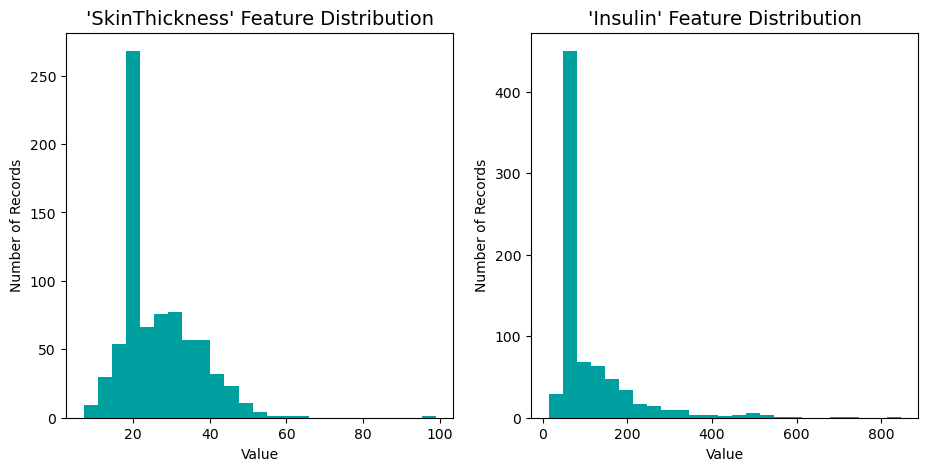

In [146]:
 #plot histograms for two columns to see how their values are spread out, SkinThickness and Insulin are skewed (many values on one side, a long tail) 
# skewed means lots of low values, a few very high so later log‑transforms those columns partly because their distributions are awkward for some models.

fig = plt.figure(figsize=(11, 5))  ## Visualize skewed continuous features of original =  data one figure, wide and short
for i, feature in enumerate(['SkinThickness', 'Insulin']):   #Loop twice: first SkinThickness, then Insulin as i is 0, then 1
    ax = fig.add_subplot(1, 2, i+1) #a 1×2 grid of plots, i+1 is position 1 then 2 (left and right).
    ax.hist(df[feature], bins=25, color='#00A0A0')  # tells histogram how many rows fall in each value range (bins)
    ax.set_title("'%s' Feature Distribution"%(feature), fontsize = 14)
    ax.set_xlabel("Value")
    ax.set_ylabel("Number of Records")

In [147]:
df.select_dtypes(include="number").skew().sort_values(key=abs, ascending=False) #to see skewed values across the list

Insulin                     3.291825
DiabetesPedigreeFunction    1.919911
BloodPressure              -1.843608
SkinThickness               1.226670
Age                         1.129597
Pregnancies                 0.901674
Outcome                     0.635017
BMI                        -0.428982
Glucose                     0.173754
dtype: float64

### DATA PREPROCESSING

handle skewness- apply log transform for natural logarithm of value + 1 so when x is 0 we get log(1)=0

In [148]:
#Log compresses large values and pulls the distribution closer to symmetric (helps some models)
#log-transform features with a long right tail and/or tons of zeros first
df["SkinThickness"] = np.log(df["SkinThickness"] + 1) #log transform the skewed features
df["Insulin"] = np.log(df["Insulin"] + 1)

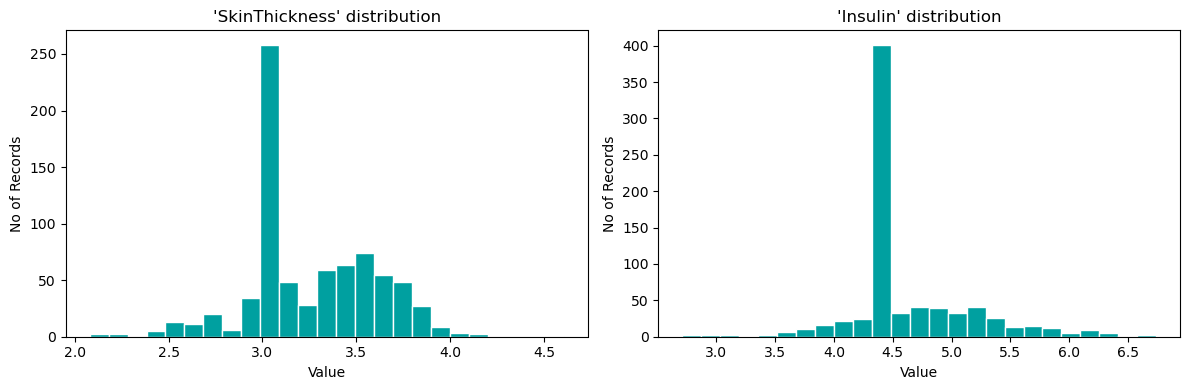

In [149]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["SkinThickness", "Insulin"]):
    ax.hist(df[col], bins=25, color="#00A0A0", edgecolor="white")
    ax.set_title(f"'{col}' distribution")
    ax.set_xlabel("Value")
    ax.set_ylabel("No of Records")
plt.tight_layout()
plt.show()

In [150]:
# TRAIN-TEST SPLIT doing before scaling to ensure no data leakage

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [151]:
# FEATURE SCALING- normalize features so model isn't biased by scale using standardscaler as it uses mean & std not min-max which can be heavily skewed by extreme value

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [152]:
# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 614 samples.
Testing set has 154 samples.


### MODEL CREATION & TRAINING

In [153]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

from sklearn.model_selection import cross_val_score

In [154]:
models = [
    ('Logistic Regression', LogisticRegression()),
    ('Support Vector Machine', SVC()),
    ('Random forest', RandomForestClassifier(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB())
]

results_list = []
for name, model in models:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_list.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.sort_values(by='F1-score', ascending=False)

print(results_df)
    

                    Model  Accuracy  Precision    Recall  F1-score
5             Naive Bayes  0.753247   0.644068  0.690909  0.666667
0     Logistic Regression  0.753247   0.649123  0.672727  0.660714
3           Decision Tree  0.740260   0.627119  0.672727  0.649123
2           Random forest  0.740260   0.636364  0.636364  0.636364
1  Support Vector Machine  0.740260   0.653061  0.581818  0.615385
4     K-Nearest Neighbors  0.727273   0.622642  0.600000  0.611111


In [155]:
results_df.style.background_gradient(cmap='Greens').format(precision=3)

,Model,Accuracy,Precision,Recall,F1-score
5,Naive Bayes,0.753,0.644,0.691,0.667
0,Logistic Regression,0.753,0.649,0.673,0.661
3,Decision Tree,0.740,0.627,0.673,0.649
2,Random forest,0.740,0.636,0.636,0.636
1,Support Vector Machine,0.740,0.653,0.582,0.615
4,K-Nearest Neighbors,0.727,0.623,0.600,0.611


### here naive bayes is best among all of them , has highest balance of catching sick people without too many false alarms, recall of this is fine too as it's great at handling independent features like age, bmi etc
LOGISTIC REGRESSION is fine too it's precision is also high in predicting actual patient , random forest and decision tree are performing well too but i'm gonna go with simpler models as dataset is smaller 

### CONFUSION MATRIX

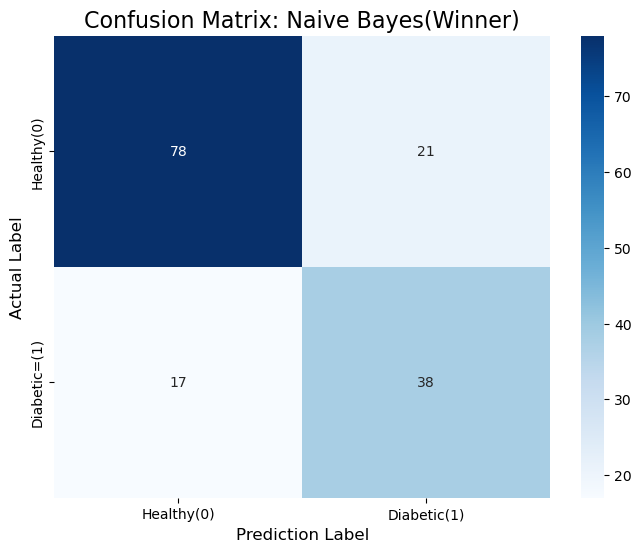

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

nb_model = GaussianNB()                            #train model
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)       #make predictions

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize = (8 , 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap='Blues',
            xticklabels = ['Healthy(0)', 'Diabetic(1)'],
            yticklabels = ['Healthy(0)', 'Diabetic=(1)'])
plt.title('Confusion Matrix: Naive Bayes(Winner)', fontsize = 16)
plt.xlabel('Prediction Label', fontsize = 12)
plt.ylabel('Actual Label', fontsize = 12)

plt.show()

### CLASSIFICATION REPORT

In [157]:
report_dict = classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Diabetic(1)'], output_dict=True)

report_df = pd.DataFrame(report_dict).transpose()

styled_report = report_df.style.format(precision=2).background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])

print("Classification Report for Naive Baiyes:")
display(styled_report)


Classification Report for Naive Baiyes:


,precision,recall,f1-score,support
Healthy (0),0.82,0.79,0.80,99.00
Diabetic(1),0.64,0.69,0.67,55.00
accuracy,0.75,0.75,0.75,0.75
macro avg,0.73,0.74,0.74,154.00
weighted avg,0.76,0.75,0.76,154.00


### ROC-AUC Curve

In [167]:
nb_model.fit(X_train, y_train) #passing raw no (arrays) directly , so model can see the columns correctly BEFORE I PASSED pandas DataFrame (excel)so now no titles and just gave pure no to modelin a grid(numpy array)

y_probs = nb_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
print(f"Unique probabilities: {len(set(y_probs))}")
print(f"Your Naive Bayes AUC Score: {roc_auc_score(y_test, y_probs):.4f}")


Unique probabilities: 154
Your Naive Bayes AUC Score: 0.8002


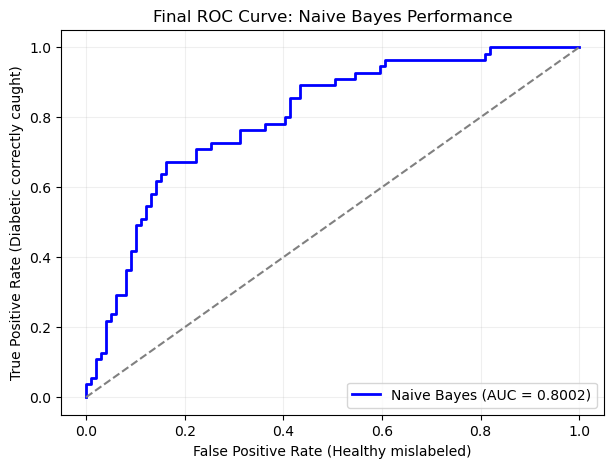

In [169]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc 

fpr, tpr , thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Naive Bayes (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (Healthy mislabeled)')
plt.ylabel('True Positive Rate (Diabetic correctly caught)')
plt.title('Final ROC Curve: Naive Bayes Performance')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

In [174]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB() #defining model

params = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]} #defining search space we try powers of 10 from 1e-9 (default) up to 1(smooth)

grid = GridSearchCV(estimator=nb, param_grid=params, cv=5, scoring='roc_auc') #set up grid search as we tell it to find best roc_auc score

grid.fit(X_train, y_train) #fitting on row array data

print(f"Best Var_smoothing: {grid.best_params_}")
print(f"Best Tuned AUC: {grid.best_score_:.4f}")

Best Var_smoothing: {'var_smoothing': 0.001}
Best Tuned AUC: 0.8018


In [180]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

#defining pipeline replacing 0 with median because pima zeroes dataset are missing values
final_pipeline = Pipeline([
    ('imputer', SimpleImputer(missing_values=0, strategy='median')),
    ('scalar', StandardScaler()),
    ('model', GaussianNB(var_smoothing=0.001))
])

from sklearn.model_selection import cross_val_score, StratifiedKFold #running leakage proof cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(final_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Stable CV AUC: {cv_auc.mean():.4f}")

# final fit and Evaluation
final_pipeline.fit(X_train, y_train)
final_probs = final_pipeline.predict_proba(X_test)[:, 1]
final_preds = final_pipeline.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, final_preds))

Stable CV AUC: 0.8046
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        99
           1       0.65      0.71      0.68        55

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



### MODEL INTEPRETATION- What is model thinking
as gaussian naive bayes doesn't have feature importance like decision tree so it learns the mean and variance of each feature for both classes 0 and 1
to interpret it i'm gonna look at the diff in feature in two classes also for diabetes glucose, BMI, age is most imp


In [186]:
import pandas as pd
model = final_pipeline.named_steps['model'] # extracting trained model from pipeline

means = model.theta_     #theta_ stores mean of each feature per class
features = X.columns       # row 0 = healthy, row 1 = diabetic

impact = abs(means[1] - means[0])              # calculating diff to see which feature seperate classes best
report = pd.DataFrame({'Feature': features, 'Impact score': impact})
report = report.sort_values(by='Impact score', ascending=False)

print("---FEATURE IMPACT (INTERPRETATION)---")
print(report)

---FEATURE IMPACT (INTERPRETATION)---
                    Feature  Impact score
1                   Glucose      1.027213
5                       BMI      0.670868
7                       Age      0.589628
0               Pregnancies      0.478480
3             SkinThickness      0.349017
4                   Insulin      0.337063
2             BloodPressure      0.335417
6  DiabetesPedigreeFunction      0.324715


### saving model - saving entire pipeline(imputer+scalar+model) into one file

In [191]:
import joblib

joblib.dump(final_pipeline, 'diabetes_final_model.pkl')
print("Done AYUSHI Project Saved! you can now use this file in any app.")

Done AYUSHI Project Saved! you can now use this file in any app.


### Creating a prediction Script - a sepearate script that loads this file and takes new patient data to give a prediction

In [194]:
import pandas as pd
import joblib

loaded_model = joblib.load('diabetes_final_model.pkl')  #to load the saved model later

feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'] #defining exact feature name model expects
new_patient_df = pd.DataFrame([[5, 160, 85, 35, 120, 38.2, 0.6, 50]],
                              columns=feature_names)
                              

prediction = loaded_model.predict(new_patient_df)
probability = loaded_model.predict_proba(new_patient_df)[:, 1]

print(f"Prediction: {'Diabetic' if prediction[0] == 1 else 'Healthy'}")
print(f"Diabtes Risk: {probability[0]:.2%}")

Prediction: Diabetic
Diabtes Risk: 93.45%


### Final Visualization

C:\Users\AYUSHI TYAGI\AppData\Local\Temp\ipykernel_19672\724976049.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Impact score', y='Feature', data=report, palette='viridis')


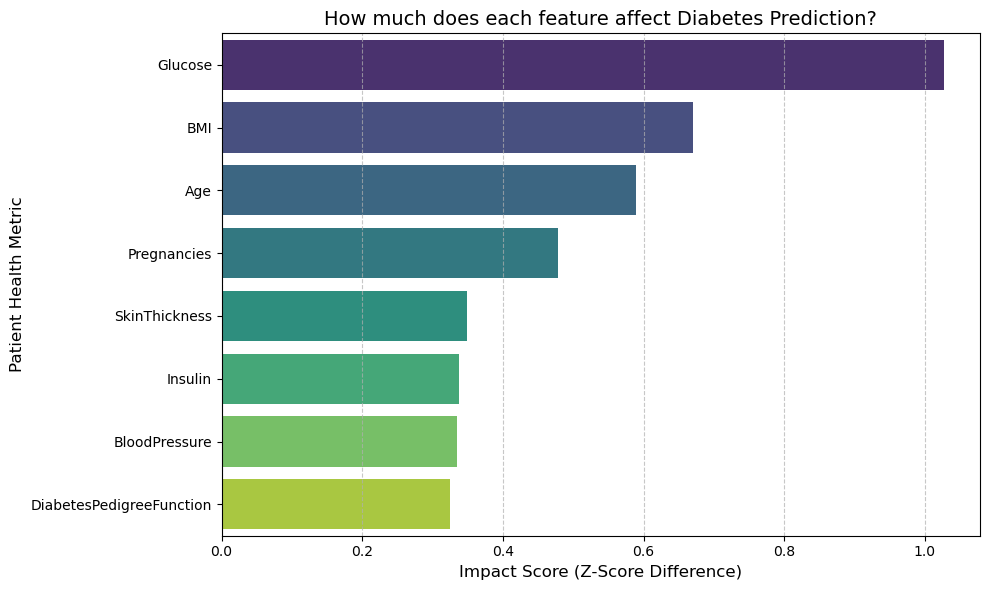

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns

# using the 'report' dataframe we created earlier
plt.figure(figsize=(10, 6))
sns.barplot(x='Impact score', y='Feature', data=report, palette='viridis')

#  professional label
plt.title('How much does each feature affect Diabetes Prediction?', fontsize=14)
plt.xlabel('Impact Score (Z-Score Difference)', fontsize=12)
plt.ylabel('Patient Health Metric', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()